In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## --- 1. Load Data ---

In [86]:
df = pd.read_csv('normalized_labeled_data.csv')
df2 = pd.read_csv('clean_unlabeled_data.csv')
print(f"Initial dataset shape: {df.shape}")
print(f"Initial dataset shape: {df2.shape}")
print(df.head())

Initial dataset shape: (8411, 26)
Initial dataset shape: (8411, 27)
   index  EventType             EventDate  HasSafetyRec  Mode  \
0      0          1  2020-12-31T18:15:00Z         False     0   
1      1          0  2020-12-31T18:00:00Z         False     0   
2      2          0  2020-12-31T15:45:00Z         False     0   
3      3          0  2020-12-31T14:49:00Z         False     0   
4      4          1  2020-12-31T02:15:00Z         False     0   

  OriginalPublishedDate HighestInjuryLevel FatalInjuryCount  \
0        12/2/2022 0:00                  ?              0.0   
1        9/20/2021 0:00                  ?              0.0   
2       10/19/2021 0:00              Minor              0.0   
3                     ?                  ?              0.0   
4                     ?                  ?                ?   

  SeriousInjuryCount MinorInjuryCount OnboardInjuryCount  Make  Model  \
0                0.0              0.0                0.0   250    303   
1               

## --- 2. Initial Inspection and Pre-Processing ---

In [87]:
# Handle '?' and Empty Strings
df.replace('?', np.nan, inplace=True)
df.replace('', np.nan, inplace=True)
df2.replace('?', np.nan, inplace=True)
df2.replace('', np.nan, inplace=True)

In [88]:
# Drop Unnecessary Columns
df.drop('index', axis=1, inplace=True)
df.drop('OriginalPublishedDate', axis=1, inplace=True)
df2.drop('index', axis=1, inplace=True)
df2.drop('OriginalPublishedDate', axis=1, inplace=True)

In [89]:
print(df['HighestInjuryLevel'].value_counts(dropna=False))
print(df2['HighestInjuryLevel'].value_counts(dropna=False))

HighestInjuryLevel
NaN        4861
Fatal      1578
Minor      1074
Serious     898
Name: count, dtype: int64
HighestInjuryLevel
NaN        4861
Fatal      1578
Minor      1074
Serious     898
Name: count, dtype: int64


In [90]:
# Define Target Variable and Handle Data Leakage
TARGET_COLUMN = 'FatalYN'
leaky_features = [
    'HighestInjuryLevel', 'FatalInjuryCount', 'SeriousInjuryCount',
    'MinorInjuryCount', 'OnboardInjuryCount'
]

existing_leaky_features = [col for col in leaky_features if col in df.columns]
#existing_leaky_features2 = [col for col in leaky_features if col in df2.columns]
df.drop(columns=existing_leaky_features, inplace=True, errors='ignore')
#df2.drop(columns=existing_leaky_features2, inplace=True, errors='ignore')

In [91]:
# Feature Engineering
df['EventDate'] = pd.to_datetime(df['EventDate'], errors='coerce')
df['EventYear'] = df['EventDate'].dt.year
df['EventMonth'] = df['EventDate'].dt.month
df['EventDay'] = df['EventDate'].dt.day
df['EventDayOfWeek'] = df['EventDate'].dt.dayofweek
df['EventHour'] = df['EventDate'].dt.hour
df.drop('EventDate', axis=1, inplace=True)

# Boolean Conversion
bool_cols_map = {'HasSafetyRec': {True: 1, False: 0}, 'AmateurBuilt': {True: 1, False: 0}}
for col, mapping in bool_cols_map.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)

truly_numerical_features = ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour']

# Add HasSafetyRec and AmateurBuilt and scale them
truly_numerical_features.append('HasSafetyRec')
truly_numerical_features.append('AmateurBuilt')

truly_numerical_features = [col for col in truly_numerical_features if col in df.columns]

# All other features (that are not the target and not in truly_numerical_features) will be treated as categorical and converted to string for one-hot encoding.
all_features = df.drop(TARGET_COLUMN, axis=1).columns.tolist()
features_to_make_categorical_str = [
    col for col in all_features if col not in truly_numerical_features
]

print(f"Features to be treated as numeric (for scaling): {truly_numerical_features}")
print(f"Features to be converted to string and one-hot encoded: {features_to_make_categorical_str}")

for col in features_to_make_categorical_str:
    if col in df.columns:
        df[col] = df[col].astype(str) # Convert to string to ensure one-hot encoding

Features to be treated as numeric (for scaling): ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour', 'HasSafetyRec', 'AmateurBuilt']
Features to be converted to string and one-hot encoded: ['EventType', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'NumberOfEngines', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType']


## --- Final Data Checks and Target Preparation ---

In [92]:
print("df.info() after type conversions:")
df.info()
print("\ndf.head() after type conversions:")
print(df.head())

# Drop rows where target is NaN
df.dropna(subset=[TARGET_COLUMN], inplace=True)
#df2.dropna(subset=[TARGET_COLUMN], inplace=True)
# Ensure target is integer
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)
#df2[TARGET_COLUMN] = df2[TARGET_COLUMN].astype(int)

print(f"\nShape after dropping rows with NaN in target: {df.shape}")
#print(f"\nShape after dropping rows with NaN in target: {df2.shape}")
print(f"Target '{TARGET_COLUMN}' value counts:\n{df[TARGET_COLUMN].value_counts(normalize=True)}")

df.info() after type conversions:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8411 entries, 0 to 8410
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   EventType             8411 non-null   object
 1   HasSafetyRec          8411 non-null   int64 
 2   Mode                  8411 non-null   object
 3   Make                  8411 non-null   object
 4   Model                 8411 non-null   object
 5   AirCraftCategory      8411 non-null   object
 6   AirportID             8411 non-null   object
 7   AmateurBuilt          8411 non-null   int64 
 8   NumberOfEngines       8411 non-null   object
 9   EngineType            8411 non-null   object
 10  PurposeOfFlight       8411 non-null   object
 11  FAR                   8411 non-null   object
 12  AirCraftDamage        8411 non-null   object
 13  WeatherCondition      8411 non-null   object
 14  BroadPhaseofFlight    8411 non-null   object
 15  Repo

## EDA Visualizations

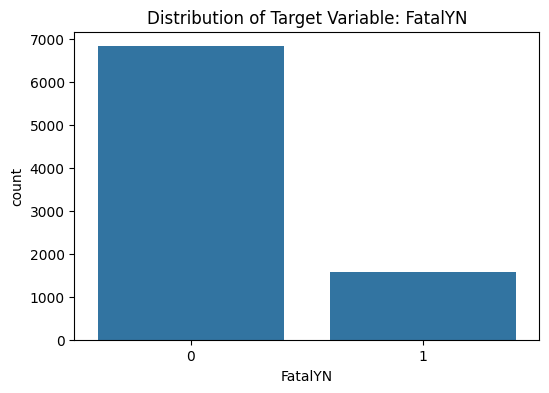

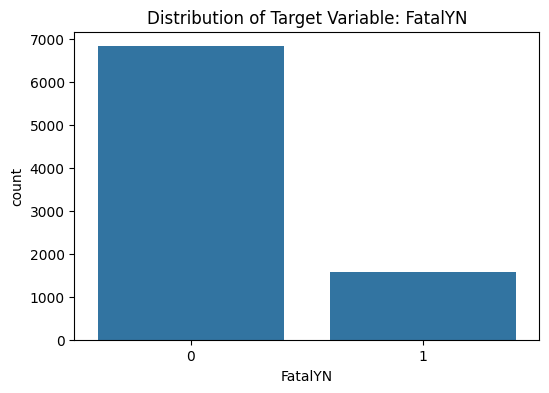

In [9]:
# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COLUMN, data=df)
plt.title(f'Distribution of Target Variable: {TARGET_COLUMN}')
plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COLUMN, data=df2)
plt.title(f'Distribution of Target Variable: {TARGET_COLUMN}')
plt.show()

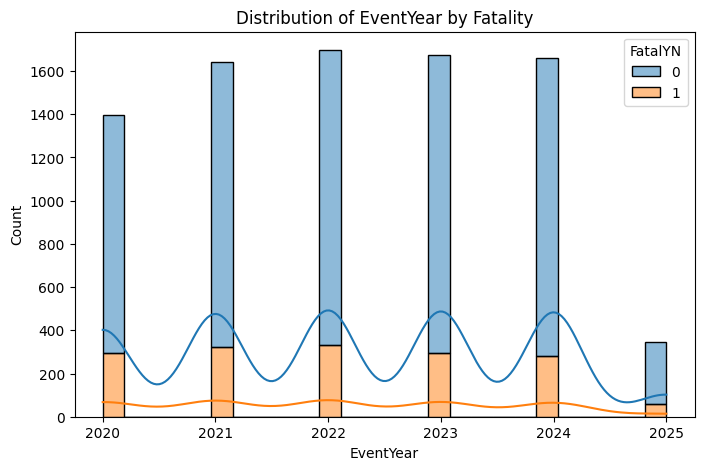

In [10]:
# Distribution of a numerical feature (EventYear)
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='EventYear', hue=TARGET_COLUMN, kde=True, multiple="stack")
plt.title('Distribution of EventYear by Fatality')
plt.show()

Counter({'3': 5895, '0': 2207, '1': 243, '2': 66})
Counter({'AIR': 7080, 'HELI': 865, nan: 177, 'GLI': 100, 'BALL': 52, 'GYRO': 46, 'WSFT': 38, 'UNMANNED': 26, 'PPAR': 18, 'ULTR': 5, 'UNK': 3, 'CSF': 1})


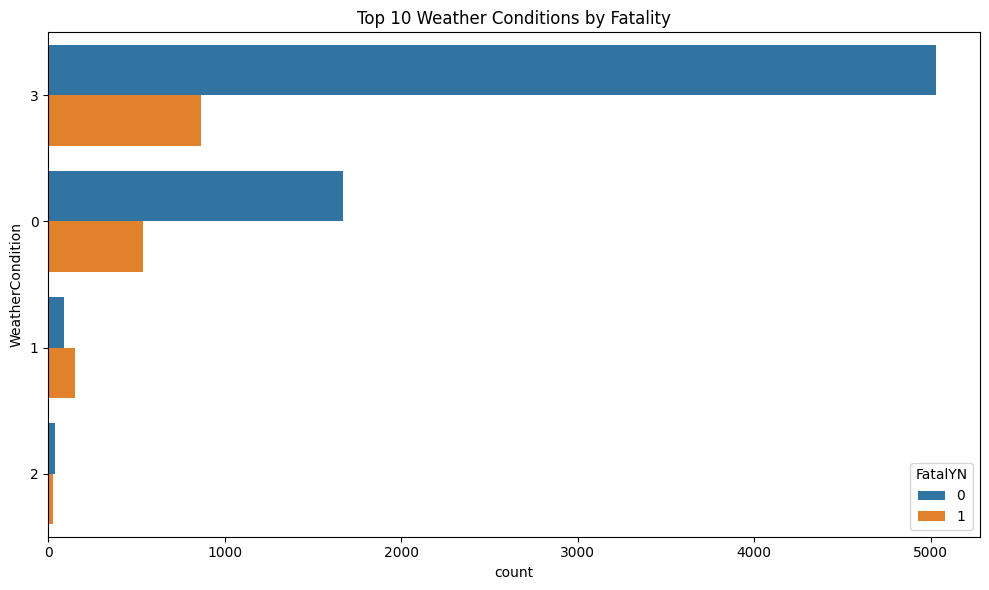

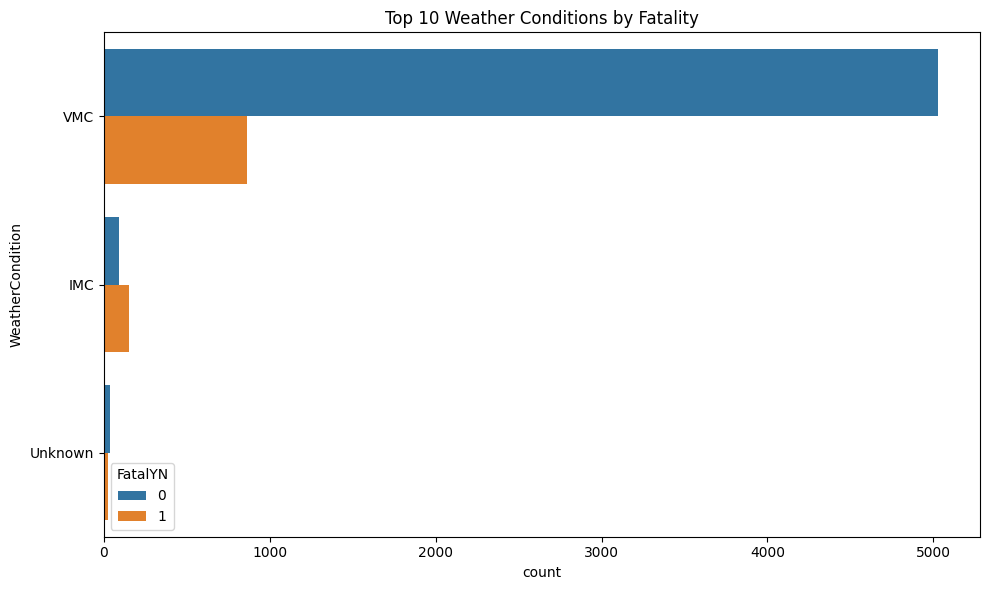

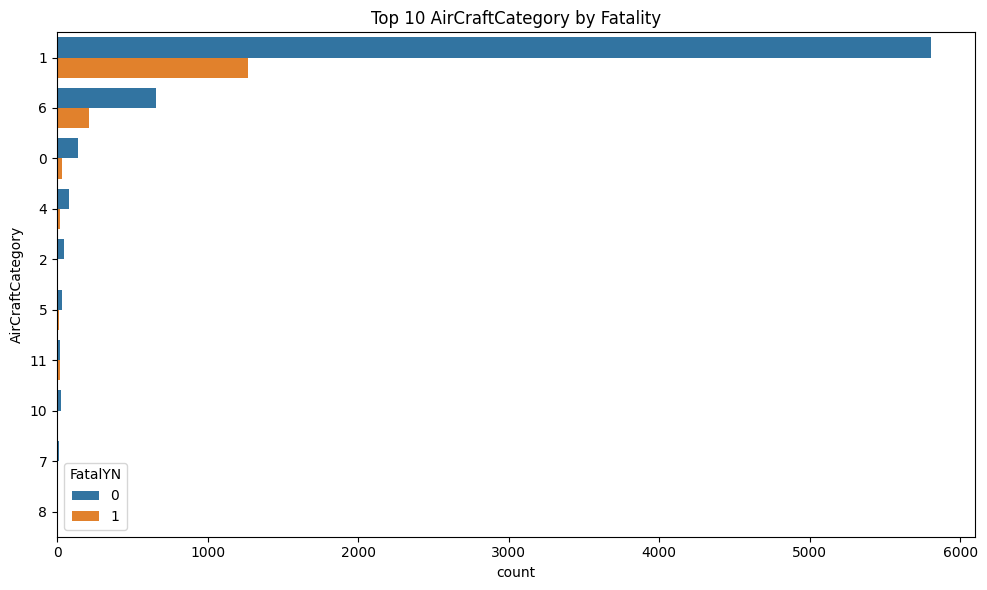

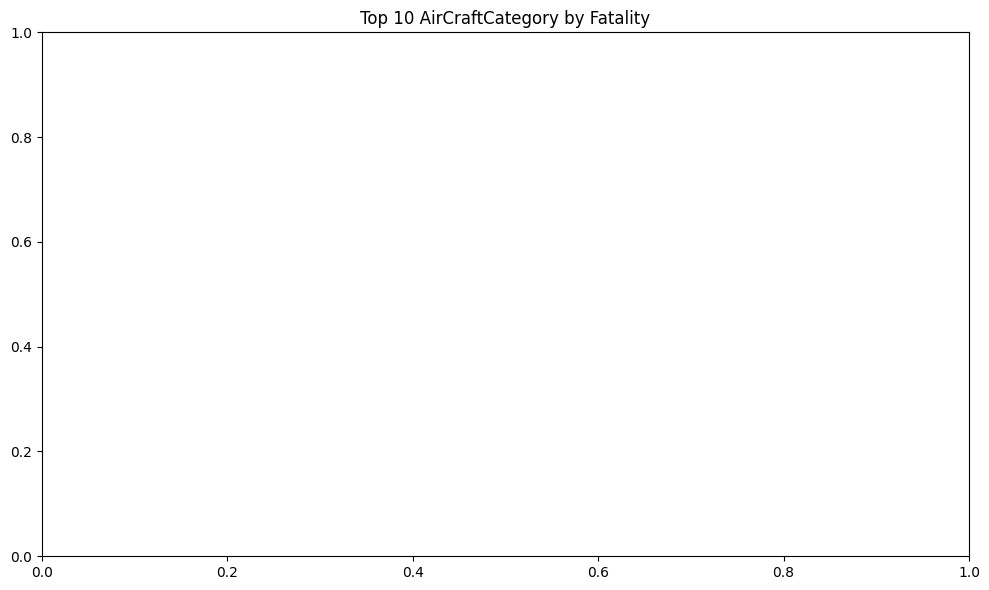

In [94]:
# Distribution of Catagorical Features
from collections import Counter 

print(Counter(df['WeatherCondition']))
print(Counter(df2['AirCraftCategory']))
top_n = 10
plt.figure(figsize=(10, 6))
top_categories = df['WeatherCondition'].value_counts().nlargest(top_n).index
sns.countplot(y='WeatherCondition', hue=TARGET_COLUMN, data=df[df['WeatherCondition'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} Weather Conditions by Fatality')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_categories = df2['WeatherCondition'].value_counts().nlargest(top_n).index
sns.countplot(y='WeatherCondition', hue=TARGET_COLUMN, data=df2[df2['WeatherCondition'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} Weather Conditions by Fatality')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
top_categories = df['AirCraftCategory'].value_counts().nlargest(top_n).index
sns.countplot(y='AirCraftCategory', hue=TARGET_COLUMN, data=df[df['AirCraftCategory'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} AirCraftCategory by Fatality')
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
top_categories = df['AirCraftCategory'].value_counts().nlargest(top_n).index
sns.countplot(y='AirCraftCategory', hue=TARGET_COLUMN, data=df2[df2['AirCraftCategory'].isin(top_categories)], order = top_categories)
plt.title(f'Top {top_n} AirCraftCategory by Fatality')
plt.tight_layout()
plt.show()

## --- Train-Test Split ---

In [12]:
X = df.drop(TARGET_COLUMN, axis=1)
y = df[TARGET_COLUMN]

In [13]:
numerical_features_for_pipeline = [col for col in truly_numerical_features if col in X.columns]
categorical_features_for_pipeline = [col for col in features_to_make_categorical_str if col in X.columns]

print(f"Features for X: {X.columns.tolist()}")
print(f"Numerical features for pipeline: {numerical_features_for_pipeline}")
print(f"Categorical features for pipeline: {categorical_features_for_pipeline}")

Features for X: ['EventType', 'HasSafetyRec', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'AmateurBuilt', 'NumberOfEngines', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType', 'EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour']
Numerical features for pipeline: ['EventYear', 'EventMonth', 'EventDay', 'EventDayOfWeek', 'EventHour', 'HasSafetyRec', 'AmateurBuilt']
Categorical features for pipeline: ['EventType', 'Mode', 'Make', 'Model', 'AirCraftCategory', 'AirportID', 'NumberOfEngines', 'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage', 'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus', 'MostRecentReportType']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")
print(X_train.columns)

X_train shape: (6728, 22), X_test shape: (1683, 22)
y_train distribution:
FatalYN
0    0.812426
1    0.187574
Name: proportion, dtype: float64
y_test distribution:
FatalYN
0    0.81224
1    0.18776
Name: proportion, dtype: float64
Index(['EventType', 'HasSafetyRec', 'Mode', 'Make', 'Model',
       'AirCraftCategory', 'AirportID', 'AmateurBuilt', 'NumberOfEngines',
       'EngineType', 'PurposeOfFlight', 'FAR', 'AirCraftDamage',
       'WeatherCondition', 'BroadPhaseofFlight', 'ReportStatus',
       'MostRecentReportType', 'EventYear', 'EventMonth', 'EventDay',
       'EventDayOfWeek', 'EventHour'],
      dtype='object')


## --- Categorical Encoding & Scaling ---

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer_cat', SimpleImputer(strategy='constant', fill_value='Missing')), # Use 'Missing' for clarity
    ('onehot', LabelEncoder())
])

# Create preprocessor with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features_for_pipeline),
        ('cat', categorical_pipeline, categorical_features_for_pipeline)
    ],
    remainder='drop'
)

# Apply transformations
print("Fitting and transforming X_train")
X_train_processed = preprocessor.fit_transform(X_train)
print(X_train_processed)

# Get feature names after one-hot encoding for better interpretability

feature_names_out = preprocessor.get_feature_names_out()
print(f"Number of features after preprocessing: {len(feature_names_out)}")


print("Transforming X_test")
X_test_processed = preprocessor.transform(X_test)

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")

Fitting and transforming X_train
[[-0.79388841 -1.40008057 -0.64431178 ...  0.          0.
   1.        ]
 [-1.46812235  0.48035769 -0.30558365 ...  0.          1.
   0.        ]
 [ 0.55457946 -1.71348695  1.16223823 ...  0.          1.
   0.        ]
 ...
 [-1.46812235  1.42057683  0.71060073 ...  0.          0.
   1.        ]
 [ 0.55457946 -0.77326782  1.16223823 ...  0.          0.
   1.        ]
 [ 1.90304733 -0.77326782  0.3718726  ...  0.          0.
   0.        ]]
Number of features after preprocessing: 5674
Transforming X_test
X_train_processed shape: (6728, 5674)
X_test_processed shape: (1683, 5674)


In [73]:
use_smote = True

## --- Oversample Minority Class for Class Imbalance using SMOTE ---

In [78]:
from imblearn.under_sampling import RandomUnderSampler
if use_smote and y_train.value_counts().min() >= 6:
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)
    print(f"Shape of X_train after SMOTE: {X_train_resampled.shape}")
    print(f"Distribution of y_train after SMOTE:\n{pd.Series(y_train_resampled).value_counts(normalize=True)}")
else:
    print("\nSMOTE failed due to insufficient samples")
    X_train_resampled, y_train_resampled = X_train_processed, y_train
    print(f"Distribution of y_train after:\n{pd.Series(y_train_resampled).value_counts(normalize=True)}")

Shape of X_train after SMOTE: (10932, 5674)
Distribution of y_train after SMOTE:
FatalYN
0    0.5
1    0.5
Name: proportion, dtype: float64


## --- Hyperparameter Tuning ---

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': randint(5, 50),
    'max_leaf_nodes': randint(10, 50),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 15),
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini']
}

search = RandomizedSearchCV(
    RandomForestClassifier(n_estimators=100, bootstrap=True),
    param_distributions=param_dist,
    n_iter=100,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1)

search.fit(X_train_resampled, y_train_resampled)

print('Best ROC: ', search.best_score_)
print("roc_auc: ", search.best_params_)

Best ROC:  0.8884321313798539
roc_auc:  {'criterion': 'gini', 'max_depth': 49, 'max_features': None, 'max_leaf_nodes': 38, 'min_samples_leaf': 4, 'min_samples_split': 14}


## --- Random Forest Model Building and Training ---

In [85]:
from sklearn.metrics import roc_curve, auc

model = RandomForestClassifier(random_state=42, criterion="gini", max_depth=20, max_features=None, max_leaf_nodes=38, min_samples_leaf=4, min_samples_split=14, n_estimators=100)

model.fit(X_train_resampled, y_train_resampled)

preds = model.predict(X_test_processed)

print(f"\n Accuracy: {accuracy_score(y_test,preds)}  ")
print(f"\n Confusion Matrix:") 
print(confusion_matrix(y_test,preds))
print(f"\n Classification Report:")
print(classification_report(y_test,preds))





 Accuracy: 0.8585858585858586  

 Confusion Matrix:
[[1241  126]
 [ 112  204]]

 Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      1367
           1       0.62      0.65      0.63       316

    accuracy                           0.86      1683
   macro avg       0.77      0.78      0.77      1683
weighted avg       0.86      0.86      0.86      1683



## --- Model Evaluation ---

Random Forest Classification Report:
               precision    recall  f1-score   support

Not Fatal (0)       0.92      0.90      0.91      1367
    Fatal (1)       0.61      0.66      0.64       316

     accuracy                           0.86      1683
    macro avg       0.77      0.78      0.77      1683
 weighted avg       0.86      0.86      0.86      1683



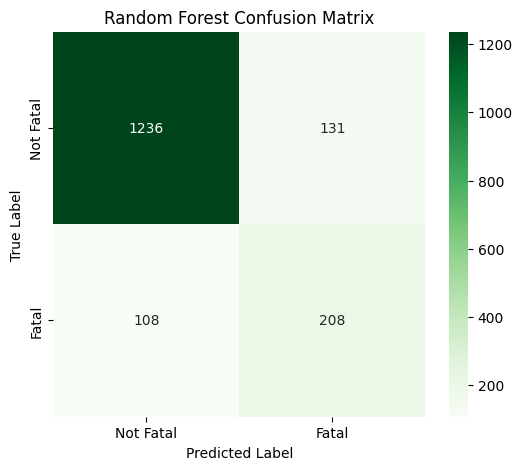

Random Forest ROC AUC Score: 0.8694


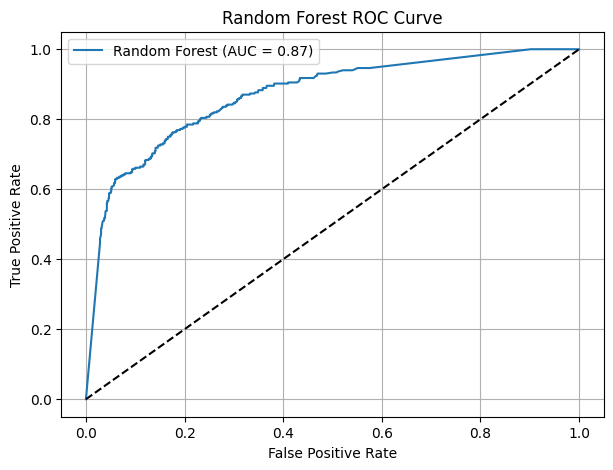

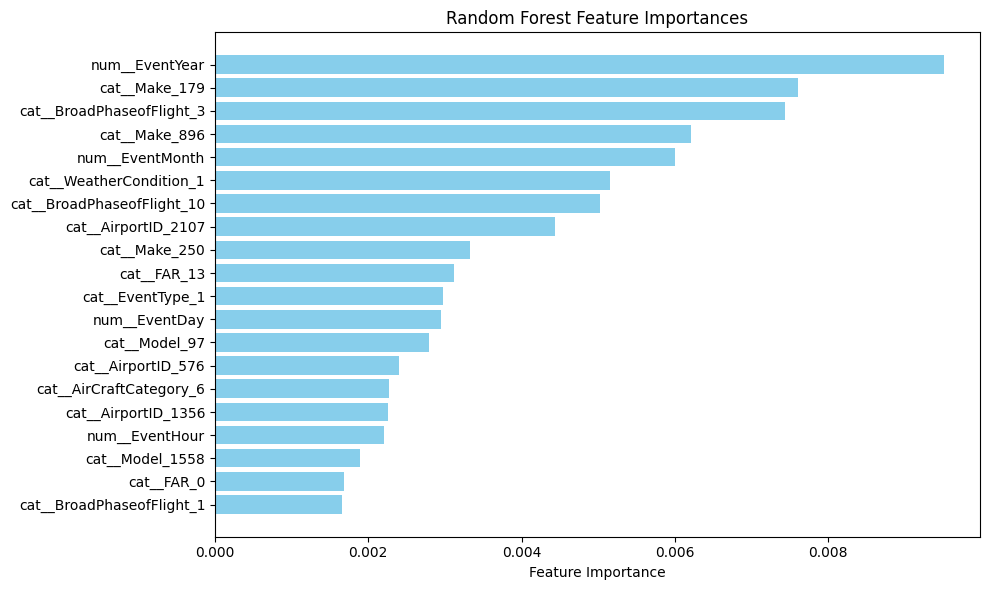

In [84]:
# Plot Model Performance

y_prob = model.predict_proba(X_test_processed)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("Random Forest Classification Report:")
print(classification_report(y_test, preds, target_names=['Not Fatal (0)', 'Fatal (1)']))

cm_rf = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['Not Fatal', 'Fatal'], yticklabels=['Not Fatal', 'Fatal'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

auc_rf = roc_auc_score(y_test, y_prob)
print(f"Random Forest ROC AUC Score: {auc_rf:.4f}")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


importances = model.feature_importances_
feature_names = feature_names_out
# Create a DataFrame for easy sorting and plotting
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
top_n = 20
feat_imp_df = feat_imp_df.loc[0:].head(top_n)
# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
import matplotlib.pyplot as plt

n_estimators_list = [10, 50, 100, 200, 300]
accuracies = []
losses = []
aucs = []

for n in n_estimators_list:
    tuningModel = RandomForestClassifier(n_estimators=n, criterion='gini', random_state=42, max_depth=10, max_features=None, max_leaf_nodes=46, min_samples_leaf=8, min_samples_split=14)
    tuningModel.fit(X_train_resampled, y_train_resampled)
    y_pred = tuningModel.predict(X_test_processed)
    y_pred_proba = tuningModel.predict_proba(X_test_processed)

    accuracies.append(accuracy_score(y_test, y_pred))
    losses.append(log_loss(y_test, y_pred_proba))
    aucs.append(roc_auc_score(y_test, y_pred_proba[:, 1]))

KeyboardInterrupt: 